In [ ]:
# Add project folder to sys.path
import sys
from pathlib import Path
project_path = Path(r"add-your-project-path-here\student-success-predictor")
sys.path.append(str(project_path))

### Imports

In [2]:
from data_exploration.utils.data_loader import DataLoader
from data_exploration.utils.data_explorer import DataExplorer
from second_term_gpa_regression.utils.data_cleaner import DataCleaner
from skimpy import skim
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import keras
import tensorflow as tf
from keras_tuner import Hyperband
import shutil
import time

from tensorflow.keras.optimizers import Adam, SGD, RMSprop


sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110})

In [3]:
# # Load the original student dataset 
# data_file = project_path / "data/Student data.csv"
# dl = DataLoader(str(data_file))
# structure_df = dl.load_and_clean_data()
# structure_df.columns.to_list()

#  # Save the cleaned dataset structure to a new CSV file
# structure_df.to_csv(project_path / "data/structured_student_data.csv", index=False)

In [4]:
# ------ Helper Classes for Custom Metrics ------
class RMSEMetric(tf.keras.metrics.Metric):
    """Dataset-level RMSE accumulated across batches."""

    def __init__(self, name="rmse", **kwargs):
        super().__init__(name=name, **kwargs)
        self.sse = self.add_weight(name="sse", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, self.dtype), [-1])
        y_pred = tf.reshape(tf.cast(y_pred, self.dtype), [-1])

        squared_errors = tf.square(y_true - y_pred)
        self.sse.assign_add(tf.reduce_sum(squared_errors))
        self.count.assign_add(tf.cast(tf.size(y_true), self.dtype))

    def result(self):
        return tf.sqrt(tf.math.divide_no_nan(self.sse, self.count))

    def reset_state(self):
        for variable in self.variables:
            variable.assign(0.0)

class R2Metric(tf.keras.metrics.Metric):
    """Dataset-level R-squared metric accumulated across batches."""

    def __init__(self, name="r2", **kwargs):
        super().__init__(name=name, **kwargs)
        self.ss_res = self.add_weight(name="ss_res", initializer="zeros")
        self.sum_y = self.add_weight(name="sum_y", initializer="zeros")
        self.sum_y_sq = self.add_weight(name="sum_y_sq", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, self.dtype), [-1])
        y_pred = tf.reshape(tf.cast(y_pred, self.dtype), [-1])

        self.ss_res.assign_add(tf.reduce_sum(tf.square(y_true - y_pred)))
        self.sum_y.assign_add(tf.reduce_sum(y_true))
        self.sum_y_sq.assign_add(tf.reduce_sum(tf.square(y_true)))
        self.count.assign_add(tf.cast(tf.size(y_true), self.dtype))

    def result(self):
        ss_tot = self.sum_y_sq - tf.square(self.sum_y) / (self.count + tf.keras.backend.epsilon())
        return 1.0 - tf.math.divide_no_nan(self.ss_res, ss_tot + tf.keras.backend.epsilon())

    def reset_state(self):
        for variable in self.variables:
            variable.assign(0.0)

In [72]:
# ----- Helper Functions -----
def print_header(name):
    """Print a compact section header."""
    print("\n" + f" {name} ".center(72, "=") + "\n")


def custom_callback(monitor, mode, patience, filepath):
    """Early stopping and model checkpoint callbacks for training."""
    es = EarlyStopping(monitor=monitor, patience=patience, restore_best_weights=True, verbose=1, mode=mode)
    mc = ModelCheckpoint(filepath=filepath, monitor=monitor, verbose=1, save_best_only=True, mode=mode)
    return es, mc


def get_target_scale(scaler_obj=None):
    scaler_obj = scaler_obj or globals().get('scaler', None)
    if scaler_obj is None or not hasattr(scaler_obj, 'data_min_') or not hasattr(scaler_obj, 'data_max_'):
        return 1.0
    return float(np.asarray(scaler_obj.data_max_ - scaler_obj.data_min_).ravel()[0])


def plot_regression_history(history, title_prefix='Model', scaler_obj=None):
    target_scale = get_target_scale(scaler_obj)
    mse_scale = target_scale ** 2

    train_mae = np.asarray(history.history['mae']) * target_scale
    val_mae = np.asarray(history.history['val_mae']) * target_scale
    train_loss = np.asarray(history.history['loss']) * mse_scale
    val_loss = np.asarray(history.history['val_loss']) * mse_scale

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(train_mae, label='Train MAE')
    axes[0].plot(val_mae, label='Val MAE')
    axes[0].set(title=f'{title_prefix} MAE', xlabel='Epoch', ylabel='MAE (GPA)')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(train_loss, label='Train Loss')
    axes[1].plot(val_loss, label='Val Loss')
    if 'rmse' in history.history:
        axes[1].plot(np.asarray(history.history['rmse']) * target_scale, '--', label='Train RMSE')
        axes[1].plot(np.asarray(history.history['val_rmse']) * target_scale, '--', label='Val RMSE')
    axes[1].set(title=f'{title_prefix} Loss & RMSE', xlabel='Epoch', ylabel='Value (GPA / GPA²)')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    if 'r2' in history.history:
        axes[2].plot(history.history['r2'], label='Train R² (Scaled y)')
        axes[2].plot(history.history['val_r2'], label='Val R² (Scaled y)')
        axes[2].set(title=f'{title_prefix} R² (Scaled y)', xlabel='Epoch', ylabel='R²')
        axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    best = int(np.argmin(history.history['val_loss']))
    get = lambda values: f"{np.asarray(values)[best]:.4f}"

    print(f"\nBest Epoch: {best + 1}")
    print('-' * 40)
    print(f"MAE (GPA)   -> Train: {get(train_mae)} | Val: {get(val_mae)}")
    if 'rmse' in history.history:
        print(f"RMSE (GPA)  -> Train: {get(np.asarray(history.history['rmse']) * target_scale)} | Val: {get(np.asarray(history.history['val_rmse']) * target_scale)}")
    print(f"Loss (GPA²) -> Train: {get(train_loss)} | Val: {get(val_loss)}")
    if 'r2' in history.history:
        print(f"R² (Scaled y) -> Train: {get(history.history['r2'])} | Val: {get(history.history['val_r2'])}")


def get_optimizer(name, learning_rate):
    if name == 'adam':
        return Adam(learning_rate=learning_rate)
    if name == 'sgd':
        return SGD(learning_rate=learning_rate, momentum=0.9)
    if name == 'rmsprop':
        return RMSprop(learning_rate=learning_rate)
    raise ValueError(f'Unsupported optimizer: {name}')


def build_dense_model(input_dim, layer_specs):
    model = keras.Sequential([keras.layers.Input(shape=(input_dim,))])
    for spec in layer_specs:
        model.add(Dense(spec['units'], activation=spec['activation']))
        if spec.get('batch_norm', False):
            model.add(BatchNormalization())
        if spec.get('dropout', 0.0) > 0:
            model.add(Dropout(spec['dropout']))
    model.add(Dense(1))
    return model


def compile_regression_model(model, optimizer_name, learning_rate):
    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate),
        loss='mse',
        metrics=['mae', RMSEMetric(name='rmse'), R2Metric(name='r2')]
    )
    return model


def inverse_transform_target(values, scaler):
    return scaler.inverse_transform(np.asarray(values).reshape(-1, 1)).flatten()


def evaluate_model_original_scale(model, X_split, y_split, scaler, split_name='Split', verbose=0, print_summary=True):
    y_pred_scaled = model.predict(X_split, verbose=verbose).ravel()
    y_true_scaled = np.asarray(y_split).ravel()
    y_true_actual = inverse_transform_target(y_split, scaler)
    y_pred_actual = inverse_transform_target(y_pred_scaled, scaler)
    r2_original = float(r2_score(y_true_actual, y_pred_actual))
    r2_scaled = float(r2_score(y_true_scaled, y_pred_scaled))

    metrics = {
        'split': split_name,
        'rmse': float(mean_squared_error(y_true_actual, y_pred_actual) ** 0.5),
        'mse': float(mean_squared_error(y_true_actual, y_pred_actual)),
        'mae': float(mean_absolute_error(y_true_actual, y_pred_actual)),
        'r2_original': r2_original,
        'r2_scaled': r2_scaled,
    }

    if print_summary:
        print(f"{split_name} RMSE: {metrics['rmse']:.4f}")
        print(f"{split_name} MSE:  {metrics['mse']:.4f}")
        print(f"{split_name} MAE:              {metrics['mae']:.4f}")
        print(f"{split_name} R² (Original GPA): {metrics['r2_original']:.4f}")
        print(f"{split_name} R² (Scaled y):     {metrics['r2_scaled']:.4f}")

    prediction_df = pd.DataFrame({
        'Actual GPA': y_true_actual,
        'Predicted GPA': y_pred_actual,
    })
    prediction_df['Residual'] = prediction_df['Actual GPA'] - prediction_df['Predicted GPA']
    prediction_df['Absolute Error'] = prediction_df['Residual'].abs()
    prediction_df['Squared Error'] = prediction_df['Residual'] ** 2
    prediction_df = prediction_df.sort_values('Absolute Error', ascending=False).reset_index(drop=True)

    return metrics, prediction_df


def format_metrics_display(df):
    return df.rename(columns={
        'rmse': 'RMSE (GPA)',
        'mse': 'MSE (GPA²)',
        'mae': 'MAE (GPA)',
        'r2_original': 'R² (Original GPA)',
        'r2_scaled': 'R² (Scaled y)',
    })


def format_local_search_display(df):
    return df.rename(columns={
        'trial': 'Trial',
        'trial_name': 'Trial Name',
        'optimizer': 'Optimizer',
        'learning_rate': 'Learning Rate',
        'batch_size': 'Batch Size',
        'best_epoch': 'Best Epoch',
        'val_rmse': 'Val RMSE (GPA)',
        'val_mae': 'Val MAE (GPA)',
        'val_r2_original': 'Val R² (Original GPA)',
        'val_r2_scaled': 'Val R² (Scaled y)',
        'test_rmse': 'Test RMSE (GPA)',
        'test_mae': 'Test MAE (GPA)',
        'test_r2_original': 'Test R² (Original GPA)',
        'test_r2_scaled': 'Test R² (Scaled y)',
        'architecture': 'Architecture',
    })


def plot_prediction_diagnostics(prediction_df, title_prefix='Model'):
    actual = prediction_df['Actual GPA']
    predicted = prediction_df['Predicted GPA']
    residuals = prediction_df['Residual']
    plot_min = min(actual.min(), predicted.min())
    plot_max = max(actual.max(), predicted.max())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.scatterplot(x=actual, y=predicted, color='#4c78a8', alpha=0.65, ax=axes[0])
    axes[0].plot([plot_min, plot_max], [plot_min, plot_max], 'r--', linewidth=1.5)
    axes[0].set_title(f'{title_prefix}: Actual vs Predicted')
    axes[0].set_xlabel('Actual GPA')
    axes[0].set_ylabel('Predicted GPA')
    axes[0].set_xlim(plot_min, plot_max)
    axes[0].set_ylim(plot_min, plot_max)
    axes[0].grid(True, alpha=0.3)

    sns.scatterplot(x=predicted, y=residuals, color='#f58518', alpha=0.65, ax=axes[1])
    axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2)
    axes[1].set_title(f'{title_prefix}: Residuals vs Predicted')
    axes[1].set_xlabel('Predicted GPA')
    axes[1].set_ylabel('Residual')
    axes[1].grid(True, alpha=0.3)

    sns.histplot(residuals, bins=20, kde=True, color='#54a24b', ax=axes[2])
    axes[2].axvline(0, color='red', linestyle='--', linewidth=1.2)
    axes[2].set_title(f'{title_prefix}: Residual Distribution')
    axes[2].set_xlabel('Residual')
    axes[2].set_ylabel('Count')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_experiment_comparison(comparison_df):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    sns.barplot(data=comparison_df, x='Model', y='r2_original', hue='Split', palette='Blues', ax=axes[0])
    axes[0].set_title('R² Comparison (Original GPA)')
    axes[0].set_ylabel('R²')
    axes[0].grid(True, axis='y', alpha=0.3)

    sns.barplot(data=comparison_df, x='Model', y='r2_scaled', hue='Split', palette='Greens', ax=axes[1])
    axes[1].set_title('R² Comparison (Scaled y)')
    axes[1].set_ylabel('R²')
    axes[1].grid(True, axis='y', alpha=0.3)

    sns.barplot(data=comparison_df, x='Model', y='rmse', hue='Split', palette='Oranges', ax=axes[2])
    axes[2].set_title('RMSE Comparison')
    axes[2].set_ylabel('RMSE (GPA)')
    axes[2].grid(True, axis='y', alpha=0.3)

    axes[1].legend_.remove()
    axes[2].legend_.remove()
    for ax in axes:
        ax.tick_params(axis='x', rotation=12)

    plt.tight_layout()
    plt.show()


def plot_local_search_summary(local_search_results_df, top_n=8):
    plot_df = local_search_results_df.copy()
    top_df = plot_df.head(top_n).copy().sort_values('val_r2_original')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.scatterplot(
        data=plot_df,
        x='val_rmse',
        y='val_r2_original',
        hue='optimizer',
        size='best_epoch',
        sizes=(60, 220),
        palette='viridis',
        ax=axes[0],
    )
    axes[0].set_title('Local Search: Validation RMSE vs R² (Original GPA)')
    axes[0].set_xlabel('Validation RMSE (GPA)')
    axes[0].set_ylabel('Validation R² (Original GPA)')
    axes[0].grid(True, alpha=0.3)

    sns.barplot(data=top_df, x='val_r2_original', y='trial_name', hue='optimizer', dodge=False, palette='Blues', ax=axes[1])
    axes[1].set_title(f'Top {top_n} Local Search Trials')
    axes[1].set_xlabel('Validation R² (Original GPA)')
    axes[1].set_ylabel('Trial')
    axes[1].grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

def get_feature_groups(feature_columns):
    base_features = [
        'first_term_gpa',
        'high_school_average_mark',
        'math_score',
        'fast_track',
        'coop',
        'residency',
        'age_group',
        'english_grade',
        'first_language',
        'funding',
        'gender',
        'previous_education',
    ]
    grouped = {}
    assigned = set()

    for feature in base_features:
        cols = [
            col for col in feature_columns
            if col == feature or (col.startswith(f'{feature}_') and not col.endswith('_missing'))
        ]
        if cols:
            grouped[feature] = cols
            assigned.update(cols)

    missing_flag_cols = [col for col in feature_columns if col.endswith('_missing')]
    for col in missing_flag_cols:
        grouped[col] = [col]
        assigned.add(col)

    for col in feature_columns:
        if col not in assigned:
            grouped[col] = [col]

    return grouped


def compute_grouped_permutation_importance(model, X_df, y_scaled, scaler, n_repeats=3, random_state=42, verbose=0):
    feature_groups = get_feature_groups(list(X_df.columns))
    rng = np.random.default_rng(random_state)
    y_true_actual = inverse_transform_target(y_scaled, scaler)
    baseline_pred_actual = inverse_transform_target(model.predict(X_df, verbose=verbose).ravel(), scaler)
    baseline_rmse = mean_squared_error(y_true_actual, baseline_pred_actual) ** 0.5
    baseline_r2 = r2_score(y_true_actual, baseline_pred_actual)

    rows = []
    for group_name, columns in feature_groups.items():
        rmse_increases = []
        r2_drops = []
        for _ in range(n_repeats):
            X_permuted = X_df.copy()
            perm_idx = rng.permutation(len(X_permuted))
            X_permuted.loc[:, columns] = X_permuted.iloc[perm_idx][columns].to_numpy()
            perm_pred_actual = inverse_transform_target(model.predict(X_permuted, verbose=verbose).ravel(), scaler)
            perm_rmse = mean_squared_error(y_true_actual, perm_pred_actual) ** 0.5
            perm_r2 = r2_score(y_true_actual, perm_pred_actual)
            rmse_increases.append(perm_rmse - baseline_rmse)
            r2_drops.append(baseline_r2 - perm_r2)

        rows.append({
            'Feature Group': group_name,
            'RMSE Increase (Mean)': float(np.mean(rmse_increases)),
            'RMSE Increase (Std)': float(np.std(rmse_increases)),
            'R² Drop (Mean)': float(np.mean(r2_drops)),
            'Grouped Columns': ', '.join(columns),
        })

    importance_df = pd.DataFrame(rows).sort_values(['RMSE Increase (Mean)', 'R² Drop (Mean)'], ascending=False).reset_index(drop=True)
    return importance_df


def plot_grouped_feature_importance(importance_df, title='Grouped Feature Importance'):
    plt.figure(figsize=(9, 6))
    sns.barplot(
        data=importance_df.sort_values('RMSE Increase (Mean)'),
        x='RMSE Increase (Mean)',
        y='Feature Group',
        hue='Feature Group',
        palette='crest',
        dodge=False,
        legend=False,
    )
    plt.title(title)
    plt.xlabel('Mean RMSE Increase after Group Permutation')
    plt.ylabel('Feature Group')
    plt.tight_layout()
    plt.show()

### Data Acquisition

In [6]:
#----- Main Code -----#
np.random.seed(42)

# Load the structured dataset
structured_data_file = project_path / "data/structured_student_data.csv"
clean_df = pd.read_csv(structured_data_file)

# Observe the dataset
skim(clean_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1437   │ │ string      │ 8     │                                                          │
│ │ Number of columns │ 15     │ │ float64     │ 7     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                    ┃ NA  ┃ NA %   ┃ mean     ┃ sd       ┃ p0  ┃ p25  ┃ p50  ┃ p75  ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ funding                   │   0 │      0 │    2.927 │    1.258 │   1 │    2 │    2 │    4 │     9 │  ▇ ▆   │  │
│ │ school                    │   0 │      0 │        6 │        0 │   6 │    6 │    6 │    6 │     6 │     ▇  │  │
│ │ fast_track                │   0 │      0 │    1.742 │   0.4378 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ coop                      │   0 │      0 │    1.695 │   0.4605 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ residency                 │   0 │      0 │    1.406 │   0.4913 │   1 │    1 │    1 │    2 │     2 │ ▇    ▅ │  │
│ │ gender                    │   0 │      0 │    1.775 │   0.4197 │   1 │    2 │    2 │    2 │     3 │  ▂  ▇  │  │
│ │ first_year_persistence    │   0 │      0 │   0.7919 │   0.4061 │   0 │    1 │    1 │    1 │     1 │ ▂    ▇ │  │
│ └───────────────────────────┴─────┴────────┴──────────┴──────────┴─────┴──────┴──────┴──────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃ column         ┃ NA ┃ NA % ┃ shortest ┃ longest  ┃ min ┃ max ┃ chars per row ┃ words per row ┃ total words ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ first_term_gpa │  0 │    0 │ 0        │ 3.020833 │ 0   │ ?   │          6.16 │             1 │        1437 │  │
│ │ second_term_gp │  0 │    0 │ 0        │ 3.923077 │ 0   │ ?   │          5.81 │             1 │        1437 │  │
│ │ a              │    │      │          │          │     │     │               │               │             │  │
│ │ first_language │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ previous_educa │  0 │    0 │ 1        │ 1        │ 0   │ ?   │             1 │             1 │        1437 │  │
│ │ tion           │    │      │          │          │     │     │               │               │             │  │
│ │ age_group      │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ high_school_av │  0 │    0 │ ?        │ 101      │ 100 │ ?   │          1.49 │             1 │        1437 │  │
│ │ erage_mark     │    │      │          │          │     │     │               │               │             │  │
│ │ math_score     │  0 │    0 │ ?        │ 16       │ 10  │ ?   │          1.68 │             1 │        1437 │  │
│ │ english_grade  │  0 │    0 │ 7        │ 10       │ 1

In [7]:
# Check the dataset by replacing ? with NaN and drop duplicates -- Cleaning is conducted later by the DataCleaner class
temp_df = clean_df
temp_df = temp_df.replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
skim(temp_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1437   │ │ float64     │ 15    │                                                          │
│ │ Number of columns │ 15     │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┓  │
│ ┃ column             ┃ NA  ┃ NA %              ┃ mean   ┃ sd     ┃ p0 ┃ p25  ┃ p50   ┃ p75   ┃ p100 ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━┩  │
│ │ first_term_gpa     │  17 │ 1.183020180932498 │  2.846 │  1.175 │  0 │ 2.25 │ 3.103 │ 3.739 │  4.5 │ ▂▁▃▆▇▇ │  │
│ │                    │     │                 3 │        │        │    │      │       │       │      │        │  │
│ │ second_term_gpa    │ 160 │ 11.13430758524704 │   2.82 │  1.129 │  0 │ 2.26 │ 3.028 │  3.68 │  4.5 │ ▂▁▃▆▇▆ │  │
│ │                    │     │                 2 │        │        │    │      │       │       │      │        │  │
│ │ first_language     │ 111 │ 7.724425887265136 │  1.911 │ 0.9949 │  1 │    1 │     1 │     3 │    3 │ ▇    ▇ │  │
│ │ funding            │   0 │                 0 │  2.927 │  1.258 │  1 │    2 │     2 │     4 │    9 │  ▇ ▆   │  │
│ │ school             │   0 │                 0 │      6 │      0 │  6 │    6 │     6 │     6 │    6 │     ▇  │  │
│ │ fast_track         │   0 │                 0 │  1.742 │ 0.4378 │  1 │    1 │     2 │     2 │    2 │ ▃    ▇ │  │
│ │ coop               │   0 │                 0 │  1.695 │ 0.4605 │  1 │    1 │     2 │     2 │    2 │ ▃    ▇ │  │
│ │ residency          │   0 │                 0 │  1.406 │ 0.4913 │  1 │    1 │     1 │     2 │    2 │ ▇    ▅ │  │
│ │ gender             │   0 │                 0 │  1.775 │ 0.4197 │  1 │    2 │     2 │     2 │    3 │  ▂  ▇  │  │
│ │ previous_education │   4 │ 0.278357689631176 │  1.275 │ 0.5678 │  0 │    1 │     1 │     2 │    2 │ ▁  ▇ ▅ │  │
│ │                    │     │                 1 │        │        │    │      │       │       │      │        │  │
│ │ age_group          │   4 │ 0.278357689631176 │  2.632 │  1.421 │  1 │    2 │     3 │     3 │    8 │ ▇▇▁▁ ▁ │  │
│ │                    │     │                 1 │        │        │    │      │       │       │      │        │  │
│ │ high_school_averag │ 743 │ 51.70494084899095 │  77.15 │  12.07 │ 17 │   70 │  77.5 │    85 │  108 │   ▂▇▇▂ │  │
│ │ e_mark             │     │                   │        │        │    │      │       │       │      │        │  │
│ │ math_score         │ 462 │ 32.15031315240083 │  32.56 │  10.71 │  6 │   23 │    32 │    43 │   50 │ ▁▅▇▇▅▇ │  │
│ │                    │     │                 4 │        │        │    │      │       │       │      │        │  │
│ │ english_grade      │  45 │ 3.131524008350730 │   8.03 │  1.716 │  1 │    7 │     8 │     9 │   10 │   ▁ ▇▇ │  │
│ │                    │     │                 5 │        │        │    │      │       │       │      │        │  │
│ │ first_year_persist │   0 │                 0 │ 0.7919 │ 0.4061 │  0 │    1 │     1 │     1 │    1 │ ▂    ▇ │  │
│ │ ence               │     │                   │      

In [8]:
# Based on the above summary target variable "second_term_gpa" has 159 null values; should be dropped for regression task. 
print(f"Number of rows before dropping nulls in target variable: {clean_df.shape[0]}")

# replace ? with nan in second_term_gpa column
clean_df["second_term_gpa"] = clean_df["second_term_gpa"].replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
print(f"Number of rows with nulls in target variable: {clean_df['second_term_gpa'].isna().sum()}")

clean_df = clean_df.dropna(subset=["second_term_gpa"])
print(f"Number of rows after dropping nulls in target variable: {clean_df.shape[0]}")

Number of rows before dropping nulls in target variable: 1437
Number of rows with nulls in target variable: 160
Number of rows after dropping nulls in target variable: 1277


In [9]:
# Feature and target separation
y = clean_df["second_term_gpa"] # Target variable
X = clean_df.drop(columns=["second_term_gpa", "first_year_persistence", "school"]) # Drop school - unique value; first_year_persistence - data leakage concerns; second_term_gpa - target variable

### Data Exploration

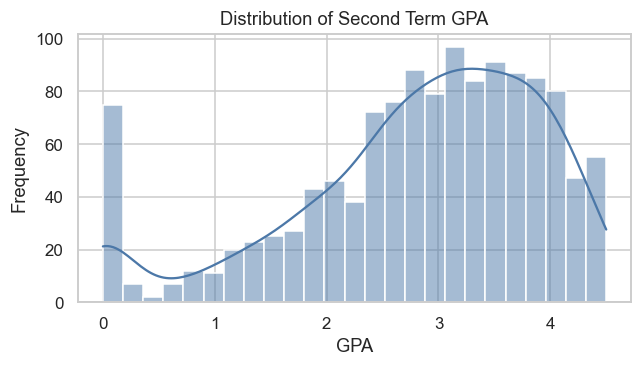

In [10]:
# explorer = DataExplorer(structured_data_file)
# explorer.run_full_analysis()

# Analyze target variable distribution
plt.figure(figsize=(6,3.5))

sns.histplot(y, bins=25, kde=True, color="#4c78a8")
plt.title("Distribution of Second Term GPA")
plt.xlabel("GPA")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [11]:
# number of students have value 0 in second_term_gpa column
num_zero_gpa = (y == 0).sum()
print(f"Number of students with second term GPA of 0: {num_zero_gpa}")

Number of students with second term GPA of 0: 72


### Train-Test Protocol

In [12]:
# test-train split with stratification and train-only feature fitting
X_train_raw, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.125,  # 10% of total
    random_state=42,
)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X_train: (893, 12), X_val: (128, 12), X_test: (256, 12)


In [13]:
# check the final training dataset
display(X_train.head())

,first_term_gpa,first_language,funding,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade
78,3.521739,3,4.0,1.0,2.0,2.0,1.0,1,3,?,?,7
353,2.25,1,2.0,2.0,2.0,1.0,2.0,2,2,83,?,7
1354,3.4,3,4.0,1.0,2.0,2.0,1.0,2,4,?,?,8
510,4.214286,1,2.0,2.0,1.0,1.0,2.0,2,4,73,49,9
338,2.547619,1,2.0,2.0,1.0,1.0,2.0,1,2,78,27,9


### Data Cleaning

In [14]:
# Data cleaning
cleaner = DataCleaner(numeric_imputer="bayesian")

X_train = cleaner.fit_transform(X_train)
X_val = cleaner.transform(X_val)
X_test = cleaner.transform(X_test)

# Target standardization
scaler = MinMaxScaler()
y_train = scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val = scaler.transform(y_val.values.reshape(-1, 1)).flatten()
y_test = scaler.transform(y_test.values.reshape(-1, 1)).flatten()


In [15]:
import joblib

# save the preprocessing pipeline (DataCleaner object) to a file for later use in inference
joblib.dump(cleaner, project_path / "second_term_gpa_regression" / "models" / "best_model" / "preprocessing_pipeline.pkl")
joblib.dump(scaler, project_path / "second_term_gpa_regression" / "models" / "best_model" / "target_scaler.pkl")

# check the training after cleaning
display(X_train.head())

,first_term_gpa,fast_track,coop,residency,age_group,high_school_average_mark,math_score,english_grade,first_term_gpa_missing,high_school_average_mark_missing,...,funding_4,funding_5,funding_8,funding_9,gender_1,gender_2,previous_education_0,previous_education_1,previous_education_2,previous_education_3
78,0.485630,1,0,0,3,0.335862,0.248844,7,0,1,...,True,False,False,False,True,False,False,True,False,False
353,-0.762264,0,0,1,2,0.270222,0.122663,7,0,0,...,False,False,False,False,False,True,False,False,True,False
1354,0.366174,1,0,0,4,0.253814,0.187655,8,0,1,...,True,False,False,False,True,False,False,False,True,False
510,1.165193,0,1,1,4,-0.751768,1.665857,9,0,0,...,False,False,False,False,False,True,False,False,True,False
338,-0.470226,0,1,1,2,-0.240773,-0.703704,9,0,0,...,False,False,False,False,False,True,False,True,False,False


### Experiment 1: Baseline Model

In [16]:
baseline_layers = [
    {'units': 128, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.2},
    {'units': 64, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.2},
    {'units': 32, 'activation': 'relu', 'batch_norm': False, 'dropout': 0.0},
]

baseline_model = build_dense_model(X_train.shape[1], baseline_layers)
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,489 (60.50 KB)

 Trainable params: 15,105 (59.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [17]:
baseline_model = compile_regression_model(baseline_model, optimizer_name='adam', learning_rate=0.001)

baseline_es, baseline_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'regression_model.keras',
)

history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[baseline_es, baseline_mc],
    verbose=1,
)

Epoch 1/200
23/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1399 - mae: 0.7997 - r2: -16.3334 - rmse: 1.0569
Epoch 1: val_loss improved from None to 0.10536, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\regression_model.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\regression_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.7338 - mae: 0.6458 - r2: -10.1397 - rmse: 0.8566 - val_loss: 0.1054 - val_mae: 0.2861 - val_r2: -0.8054 - val_rmse: 0.3246
Epoch 2/200
23/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3472 - mae: 0.4502 - r2: -4.7877 - rmse: 0.5888
Epoch 2: val_loss did not improve from 0.10536
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3097 - mae: 0.4247 - r2: -3.7015 - rmse: 0.5565 - val_loss: 0.1237 - val_mae: 0.3161 - val_r2: -1.1195 - val_rmse: 0.35

### Baseline Evaluation

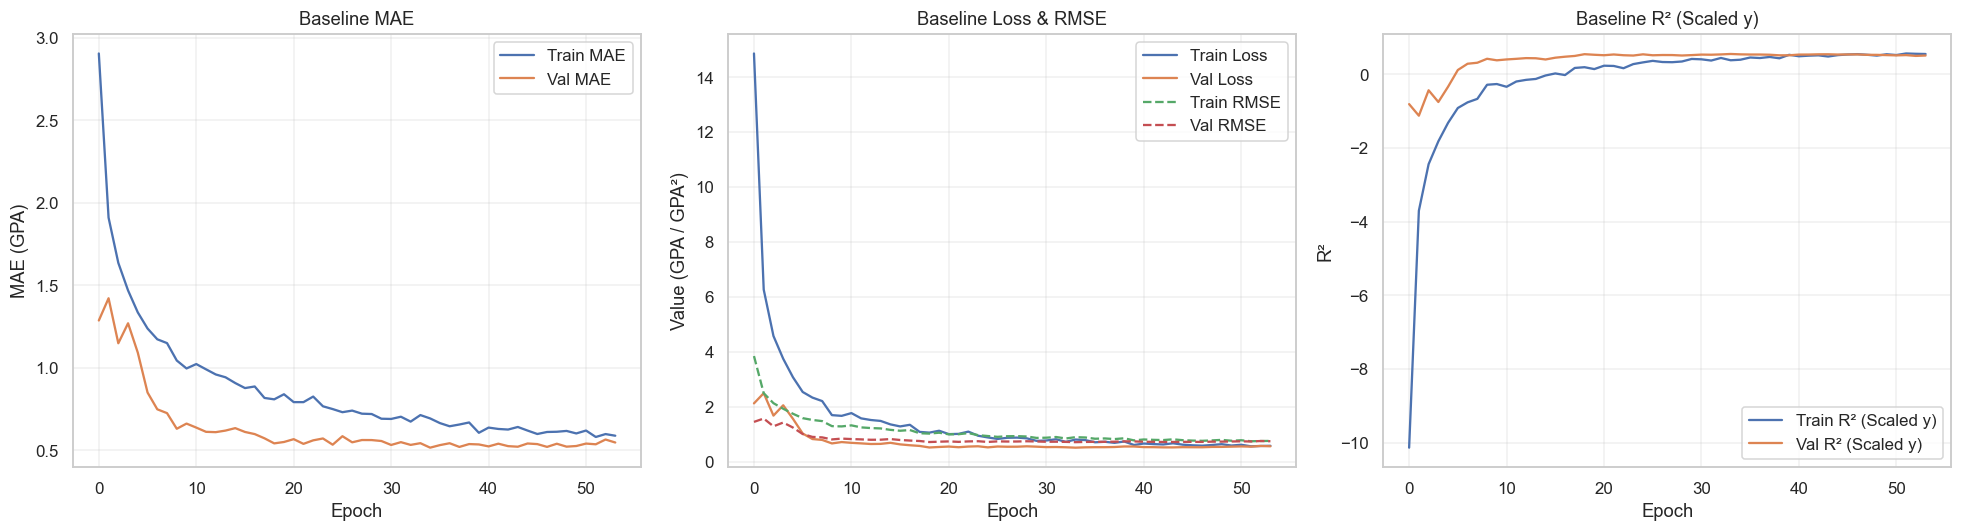


Best Epoch: 34
----------------------------------------
MAE (GPA)   -> Train: 0.7143 | Val: 0.5440
RMSE (GPA)  -> Train: 0.9047 | Val: 0.7233
Loss (GPA²) -> Train: 0.8186 | Val: 0.5232
R² (Scaled y) -> Train: 0.3863 | Val: 0.5573


In [18]:
plot_regression_history(history_baseline, title_prefix='Baseline')

In [19]:
baseline_val_metrics, baseline_val_df = evaluate_model_original_scale(
    baseline_model, X_val, y_val, scaler, split_name='Baseline Validation'
)
baseline_test_metrics, baseline_test_df = evaluate_model_original_scale(
    baseline_model, X_test, y_test, scaler, split_name='Baseline Test'
)

baseline_summary_df = pd.DataFrame([baseline_val_metrics, baseline_test_metrics]).set_index('split')
display(format_metrics_display(baseline_summary_df))
display(baseline_test_df.head(15))

Baseline Validation RMSE: 0.7233
Baseline Validation MSE:  0.5232
Baseline Validation MAE:              0.5440
Baseline Validation R² (Original GPA): 0.5573
Baseline Validation R² (Scaled y):     0.5573
Baseline Test RMSE: 0.6546
Baseline Test MSE:  0.4285
Baseline Test MAE:              0.5036
Baseline Test R² (Original GPA): 0.6116
Baseline Test R² (Scaled y):     0.6116


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Baseline Validation,0.723310,0.523177,0.543962,0.557304,0.557304
Baseline Test,0.654601,0.428503,0.503633,0.611594,0.611594


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,0.000000,2.529080,-2.529080,2.529080,6.396246
1,3.000000,0.723894,2.276106,2.276106,5.180659
2,0.000000,2.114198,-2.114198,2.114198,4.469834
3,3.333333,5.245767,-1.912434,1.912434,3.657402
4,2.978261,1.142716,1.835545,1.835545,3.369226
5,3.760870,2.091059,1.669811,1.669811,2.788270
6,3.222222,1.593712,1.628510,1.628510,2.652046
7,1.857143,0.312873,1.544270,1.544270,2.384769
8,0.000000,1.430976,-1.430976,1.430976,2.047692
9,3.375000,1.982754,1.392246,1.392246,1.938350


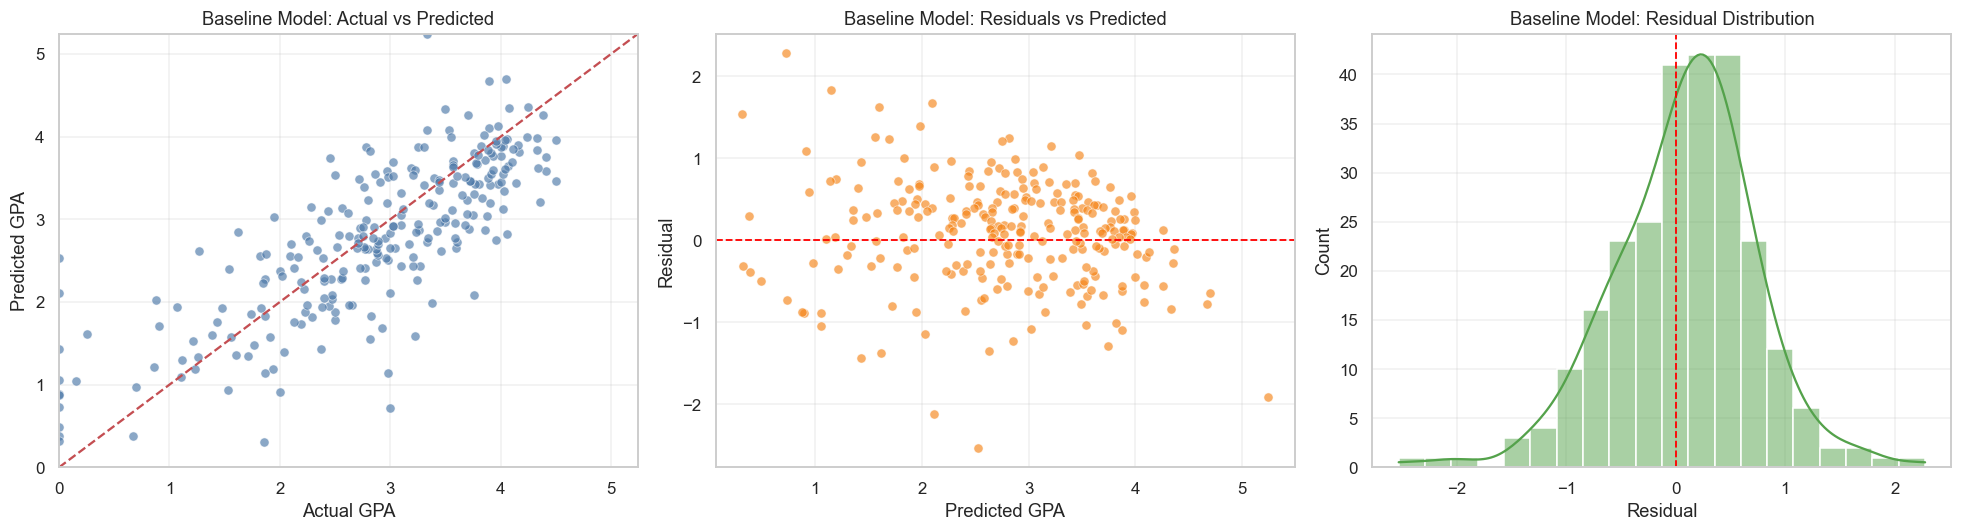

In [20]:
plot_prediction_diagnostics(baseline_test_df, title_prefix='Baseline Model')

### Experiment 2: Keras Tuner - Automatic Hyperband Search

In [21]:
def build_tuner_model(hp):
    layer_specs = []
    num_layers = hp.Int('num_layers', 1, 3)

    for i in range(num_layers):
        layer_specs.append({
            'units': hp.Choice(f'neurons_{i}', [64, 128, 256, 512]),
            'activation': hp.Choice(f'act_{i}', ['relu', 'tanh', 'elu']),
            'batch_norm': True,
            'dropout': hp.Float(f'dropout_{i}', 0.1, 0.5, step=0.1),
        })

    tuner_model = build_dense_model(X_train.shape[1], layer_specs)
    optimizer_name = hp.Choice('optimizer', ['adam', 'sgd', 'rmsprop'])
    learning_rate = hp.Choice('learning_rate', [0.0001, 0.0005, 0.001, 0.002, 0.003, 0.004, 0.005, 0.01])
    tuner_model = compile_regression_model(tuner_model, optimizer_name=optimizer_name, learning_rate=learning_rate)
    return tuner_model


def show_best_hyperparameters(hyperparameters):
    rows = [{'hyperparameter': k, 'value': v} for k, v in hyperparameters.values.items()]
    display(pd.DataFrame(rows))

In [22]:
tuner_dir = project_path / 'second_term_gpa_regression' / 'tuner' / 'student_tuner'
if tuner_dir.exists():
    shutil.rmtree(tuner_dir, ignore_errors=True)

print_header('KERAS TUNER SEARCH')

hyperband_tuner = Hyperband(
    hypermodel=build_tuner_model,
    objective='val_loss',
    max_epochs=40,
    factor=3,
    directory=tuner_dir,
    project_name='student_tuner',
    seed=42,
    overwrite=True,
)

search_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=0,
    mode='min',
)

search_start = time.time()
hyperband_tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    callbacks=[search_stop],
    verbose=1,
)
search_time = time.time() - search_start

print(f'Search completed in {search_time / 60:.1f} minutes')
hyperband_tuner.results_summary(num_trials=10)

best_hps = hyperband_tuner.get_best_hyperparameters(1)[0]
print_header('BEST HYPERPARAMETERS')
show_best_hyperparameters(best_hps)

Trial 90 Complete [00h 00m 17s]
val_loss: 0.023759707808494568

Best val_loss So Far: 0.021748943254351616
Total elapsed time: 00h 11m 22s
Search completed in 11.4 minutes
Results summary
Results in C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\tuner\student_tuner\student_tuner
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 0083 summary
Hyperparameters:
num_layers: 1
neurons_0: 64
act_0: tanh
dropout_0: 0.1
optimizer: sgd
learning_rate: 0.004
neurons_1: 256
act_1: relu
dropout_1: 0.2
neurons_2: 256
act_2: tanh
dropout_2: 0.30000000000000004
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0076
Score: 0.021748943254351616

Trial 0077 summary
Hyperparameters:
num_layers: 1
neurons_0: 256
act_0: elu
dropout_0: 0.4
optimizer: sgd
learning_rate: 0.001
neurons_1: 64
act_1: relu
dropout_1: 0.4
neurons_2: 256
act_2: elu
dropout_2: 0.4
tuner/epochs: 14
tuner/i

,hyperparameter,value
0,num_layers,1
1,neurons_0,64
2,act_0,tanh
3,dropout_0,0.1
4,optimizer,sgd
5,learning_rate,0.004
6,neurons_1,256
7,act_1,relu
8,dropout_1,0.2
9,neurons_2,256


### Hyperband Results

In [23]:
all_trials = list(hyperband_tuner.oracle.trials.values())
target_scale = get_target_scale(scaler)
mse_scale = target_scale ** 2

tuning_results_df = pd.DataFrame([
    {
        'Loss (GPA²)': (t.metrics.metrics['loss'].get_best_value() * mse_scale) if 'loss' in t.metrics.metrics else None,
        'Val_Loss (GPA²)': (t.metrics.metrics['val_loss'].get_best_value() * mse_scale) if 'val_loss' in t.metrics.metrics else None,
        'MAE (GPA)': (t.metrics.metrics['mae'].get_best_value() * target_scale) if 'mae' in t.metrics.metrics else None,
        'Val_MAE (GPA)': (t.metrics.metrics['val_mae'].get_best_value() * target_scale) if 'val_mae' in t.metrics.metrics else None,
        'RMSE (GPA)': (t.metrics.metrics['rmse'].get_best_value() * target_scale) if 'rmse' in t.metrics.metrics else None,
        'Val_RMSE (GPA)': (t.metrics.metrics['val_rmse'].get_best_value() * target_scale) if 'val_rmse' in t.metrics.metrics else None,
        'R2 (Scaled y)': t.metrics.metrics['r2'].get_best_value() if 'r2' in t.metrics.metrics else None,
        'Val_R2 (Scaled y)': t.metrics.metrics['val_r2'].get_best_value() if 'val_r2' in t.metrics.metrics else None,
        **t.hyperparameters.values,
    }
    for t in all_trials
]).sort_values('Val_Loss (GPA²)', ascending=True).reset_index(drop=True)

tuning_results_df.insert(0, 'ID', range(1, len(tuning_results_df) + 1))
tuning_results_df.to_csv(
    project_path / 'second_term_gpa_regression' / 'trial_results' / 'keras_tuner_results_regression_bayesian.csv',
    index=False,
)

print('TOP 20 BEST TRIALS (loss/MAE/RMSE in original GPA scale, R² in scaled y)')
print(tuning_results_df.head(20).to_string(index=False))

TOP 20 BEST TRIALS (loss/MAE/RMSE in original GPA scale, R² in scaled y)
 ID  Loss (GPA²)  Val_Loss (GPA²)  MAE (GPA)  Val_MAE (GPA)  RMSE (GPA)  Val_RMSE (GPA)  R2 (Scaled y)  Val_R2 (Scaled y)  num_layers  neurons_0 act_0  dropout_0 optimizer  learning_rate  tuner/epochs  tuner/initial_epoch  tuner/bracket  tuner/round  neurons_1 act_1  dropout_1  neurons_2 act_2  dropout_2 tuner/trial_id
  1     0.529240         0.440416   0.544142       0.445074    0.727489        0.663639       0.603234           0.627334           1         64  tanh        0.1       sgd          0.004            40                   14              1            1        256  relu        0.2      256.0  tanh        0.3           0076
  2     0.634848         0.443028   0.609405       0.476419    0.796773        0.665603       0.524061           0.625124           1        256   elu        0.4       sgd          0.001            14                    0              1            0         64  relu        0.4      25

In [24]:
best_model = hyperband_tuner.hypermodel.build(best_hps)
best_model.summary()

best_es, best_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'best_regression_model_bayesian.keras',
)

history_best = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    callbacks=[best_es, best_mc],
    verbose=1,
)

print('Training completed.')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 64)                  │           2,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,369 (9.25 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/200
17/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.6260 - mae: 0.9591 - r2: -26.2621 - rmse: 1.2480
Epoch 1: val_loss improved from None to 0.17900, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_regression_model_bayesian.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_regression_model_bayesian.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.6735 - mae: 0.5836 - r2: -9.2252 - rmse: 0.8207 - val_loss: 0.1790 - val_mae: 0.3828 - val_r2: -2.0672 - val_rmse: 0.4231
Epoch 2/200
19/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1791 - mae: 0.2933 - r2: -1.9392 - rmse: 0.4213 
Epoch 2: val_loss improved from 0.17900 to 0.04701, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\mode

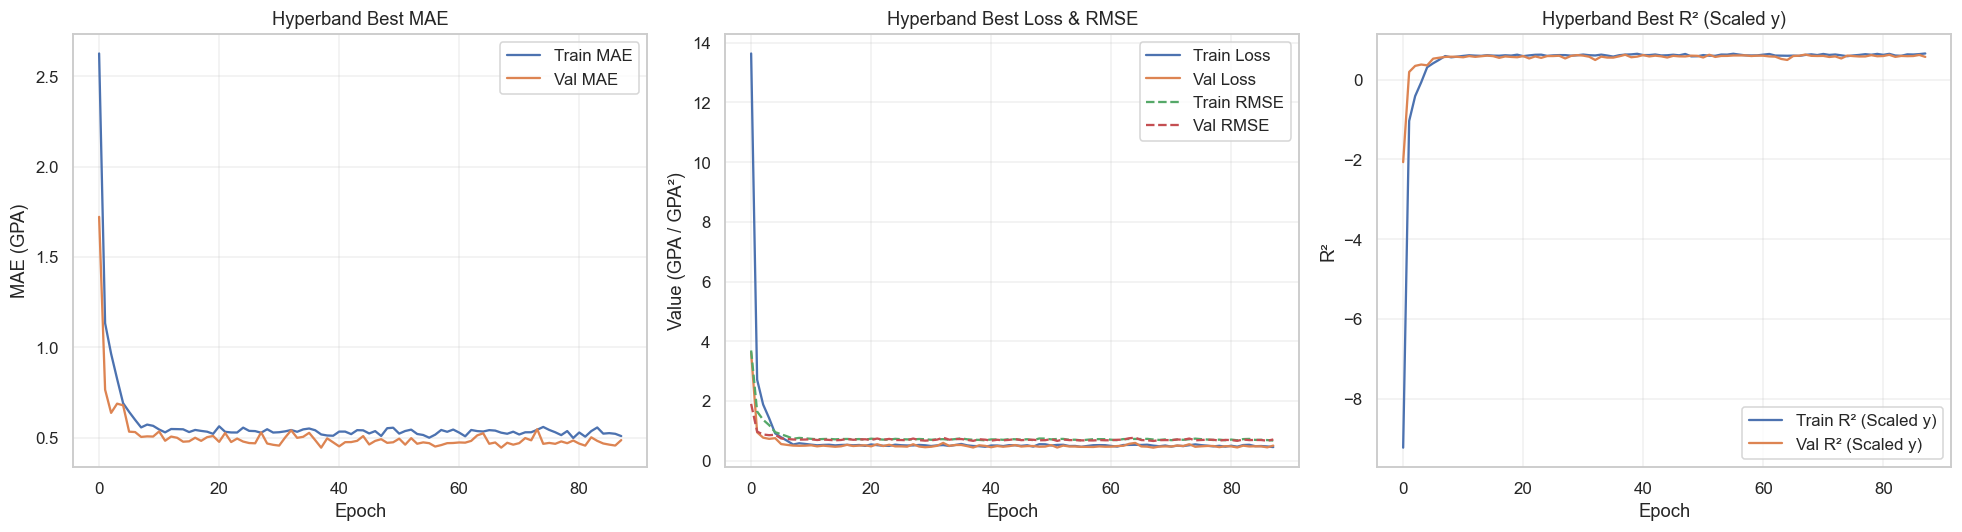


Best Epoch: 68
----------------------------------------
MAE (GPA)   -> Train: 0.5286 | Val: 0.4459
RMSE (GPA)  -> Train: 0.7116 | Val: 0.6617
Loss (GPA²) -> Train: 0.5064 | Val: 0.4379
R² (Scaled y) -> Train: 0.6204 | Val: 0.6295


In [25]:
plot_regression_history(history_best, title_prefix='Hyperband Best')

In [26]:
best_val_metrics, best_val_df = evaluate_model_original_scale(
    best_model, X_val, y_val, scaler, split_name='Hyperband Validation'
)
best_test_metrics, best_test_df = evaluate_model_original_scale(
    best_model, X_test, y_test, scaler, split_name='Hyperband Test'
)

best_summary_df = pd.DataFrame([best_val_metrics, best_test_metrics]).set_index('split')
display(format_metrics_display(best_summary_df))
display(best_test_df.head(15))

Hyperband Validation RMSE: 0.6617
Hyperband Validation MSE:  0.4379
Hyperband Validation MAE:              0.4459
Hyperband Validation R² (Original GPA): 0.6295
Hyperband Validation R² (Scaled y):     0.6295
Hyperband Test RMSE: 0.5772
Hyperband Test MSE:  0.3332
Hyperband Test MAE:              0.4424
Hyperband Test R² (Original GPA): 0.6980
Hyperband Test R² (Scaled y):     0.6980


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Hyperband Validation,0.661731,0.437888,0.445898,0.629474,0.629474
Hyperband Test,0.577222,0.333185,0.442390,0.697993,0.697993


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,3.000000,0.947292,2.052708,2.052708,4.213610
1,0.000000,1.726179,-1.726179,1.726179,2.979696
2,0.250000,1.949843,-1.699843,1.699843,2.889467
3,0.000000,1.672055,-1.672055,1.672055,2.795768
4,2.978261,1.314988,1.663273,1.663273,2.766477
5,0.000000,1.541110,-1.541110,1.541110,2.375021
6,0.000000,1.453086,-1.453086,1.453086,2.111458
7,1.619048,3.038306,-1.419258,1.419258,2.014294
8,3.375000,2.016618,1.358382,1.358382,1.845202
9,2.815789,4.122196,-1.306407,1.306407,1.706700


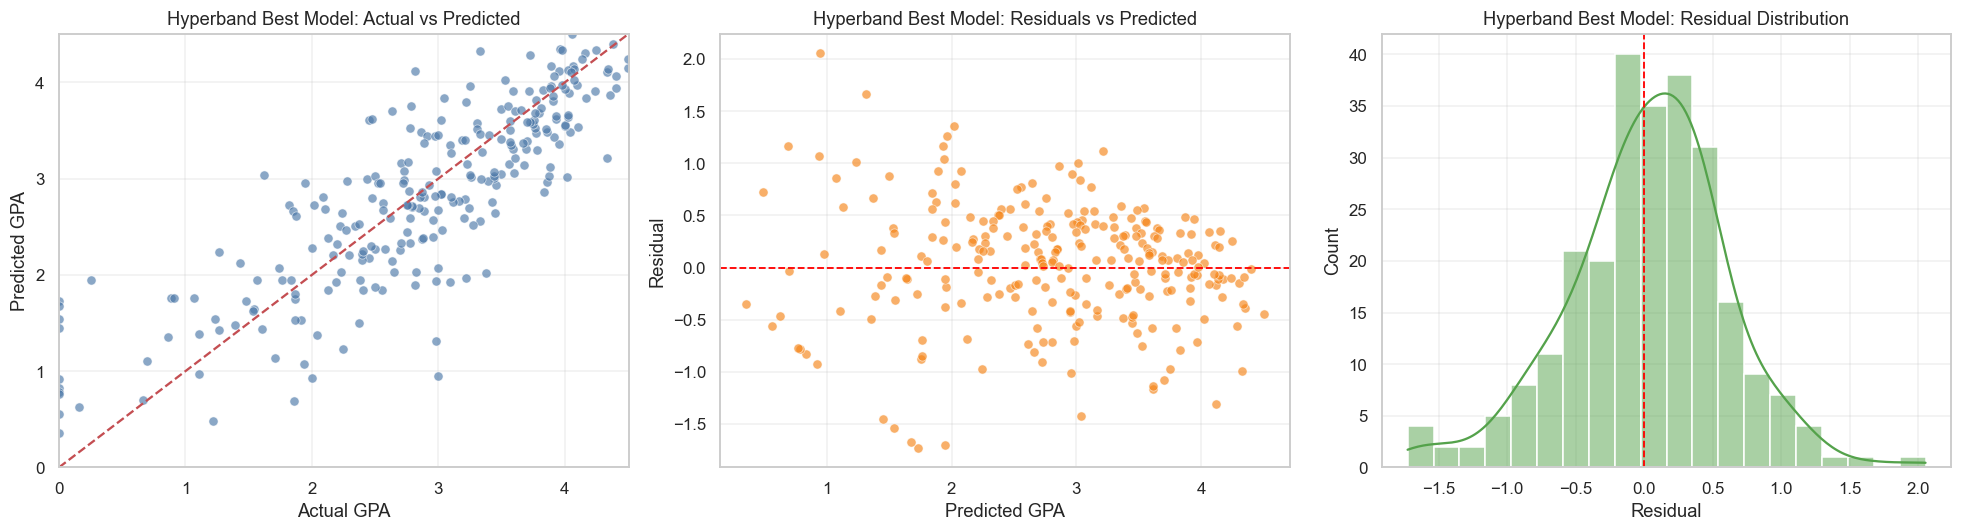

In [27]:
plot_prediction_diagnostics(best_test_df, title_prefix='Hyperband Best Model')

### Experiment 3: Custom Model based on Hyperband Findings

In [52]:
custom_layers = [
    {'units': 516, 'activation': 'tanh', 'batch_norm': True, 'dropout': 0.1},
    {'units': 128, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.2},
]

custom_model = build_dense_model(X_train.shape[1], custom_layers)
custom_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                     │ (None, 516)                 │          17,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 516)                 │           2,064 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 516)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 128)                 │          66,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 86,425 (337.60 KB)

 Trainable params: 85,137 (332.57 KB)

 Non-trainable params: 1,288 (5.03 KB)

In [53]:
custom_model = compile_regression_model(custom_model, optimizer_name='sgd', learning_rate=0.0009)

custom_es, custom_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'custom_model_bayesian.keras',
)

history_custom = custom_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    callbacks=[custom_es, custom_mc],
    verbose=1,
)

Epoch 1/200
26/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.2838 - mae: 1.0972 - r2: -32.2987 - rmse: 1.4951
Epoch 1: val_loss improved from None to 0.17043, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\custom_model_bayesian.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\custom_model_bayesian.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 1.5149 - mae: 0.9167 - r2: -21.9974 - rmse: 1.2308 - val_loss: 0.1704 - val_mae: 0.3776 - val_r2: -1.9202 - val_rmse: 0.4128
Epoch 2/200
24/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5575 - mae: 0.5691 - r2: -6.6797 - rmse: 0.7456
Epoch 2: val_loss did not improve from 0.17043
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4500 - mae: 0.5112 - r2: -5.8314 - rmse: 0.6708 - val_loss: 0.3162 - val_mae: 0.5153 - val_r2: -4.4180 - val_

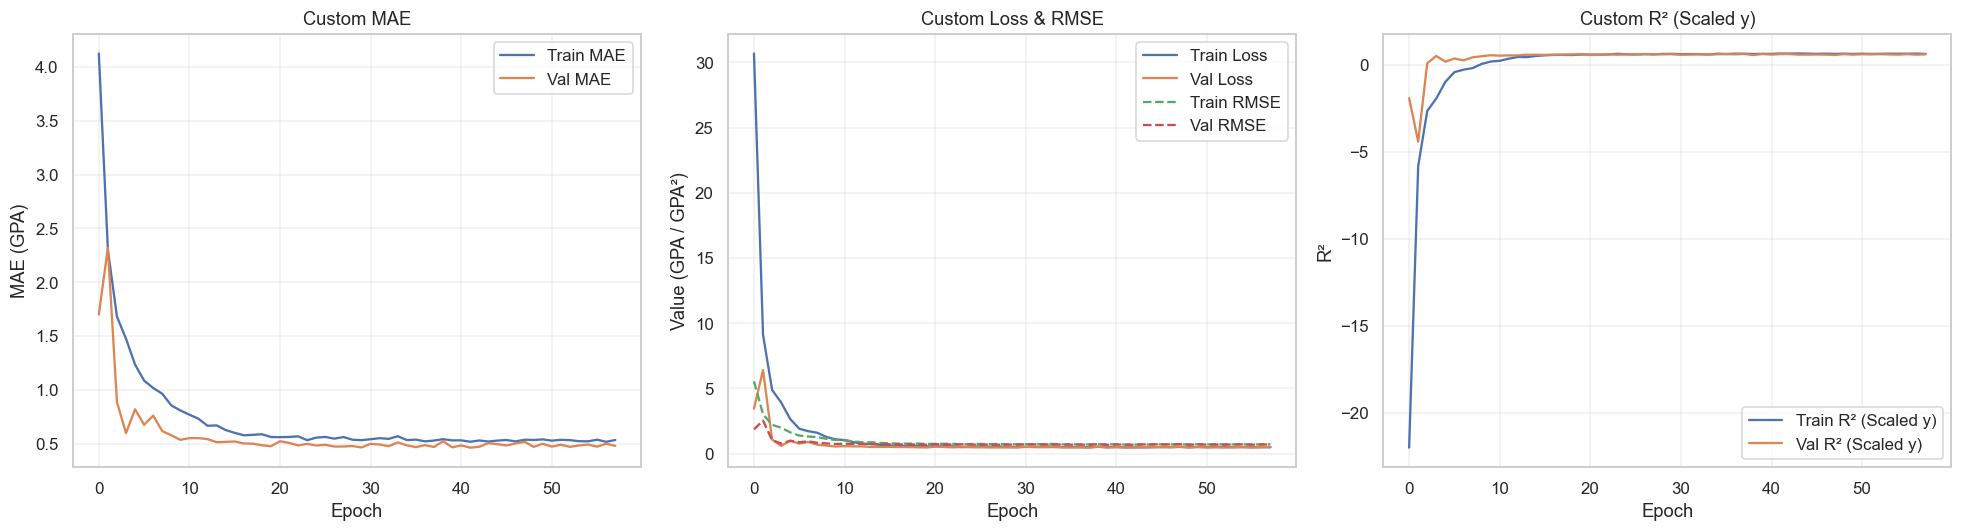


Best Epoch: 38
----------------------------------------
MAE (GPA)   -> Train: 0.5279 | Val: 0.4681
RMSE (GPA)  -> Train: 0.7036 | Val: 0.6747
Loss (GPA²) -> Train: 0.4951 | Val: 0.4552
R² (Scaled y) -> Train: 0.6289 | Val: 0.6149


In [54]:
plot_regression_history(history_custom, title_prefix='Custom')

In [57]:
custom_val_metrics, custom_val_df = evaluate_model_original_scale(
    custom_model, X_val, y_val, scaler, split_name='Custom Validation'
)
custom_test_metrics, custom_test_df = evaluate_model_original_scale(
    custom_model, X_test, y_test, scaler, split_name='Custom Test'
)

custom_summary_df = pd.DataFrame([custom_val_metrics, custom_test_metrics]).set_index('split')
display(format_metrics_display(custom_summary_df))
display(custom_test_df.head(15))

Custom Validation RMSE: 0.6747
Custom Validation MSE:  0.4552
Custom Validation MAE:              0.4681
Custom Validation R² (Original GPA): 0.6149
Custom Validation R² (Scaled y):     0.6149
Custom Test RMSE: 0.5652
Custom Test MSE:  0.3195
Custom Test MAE:              0.4285
Custom Test R² (Original GPA): 0.7104
Custom Test R² (Scaled y):     0.7104


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Custom Validation,0.674653,0.455157,0.468106,0.614861,0.614861
Custom Test,0.565216,0.319469,0.428476,0.710426,0.710426


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,0.000000,1.943884,-1.943884,1.943884,3.778683
1,3.000000,1.136617,1.863383,1.863383,3.472196
2,0.250000,2.036263,-1.786263,1.786263,3.190735
3,0.000000,1.712631,-1.712631,1.712631,2.933104
4,0.000000,1.616935,-1.616935,1.616935,2.614478
5,2.978261,1.434296,1.543965,1.543965,2.383828
6,0.000000,1.484668,-1.484668,1.484668,2.204238
7,1.619048,2.962075,-1.343027,1.343027,1.803722
8,2.454545,3.732849,-1.278304,1.278304,1.634060
9,3.375000,2.138896,1.236104,1.236104,1.527953


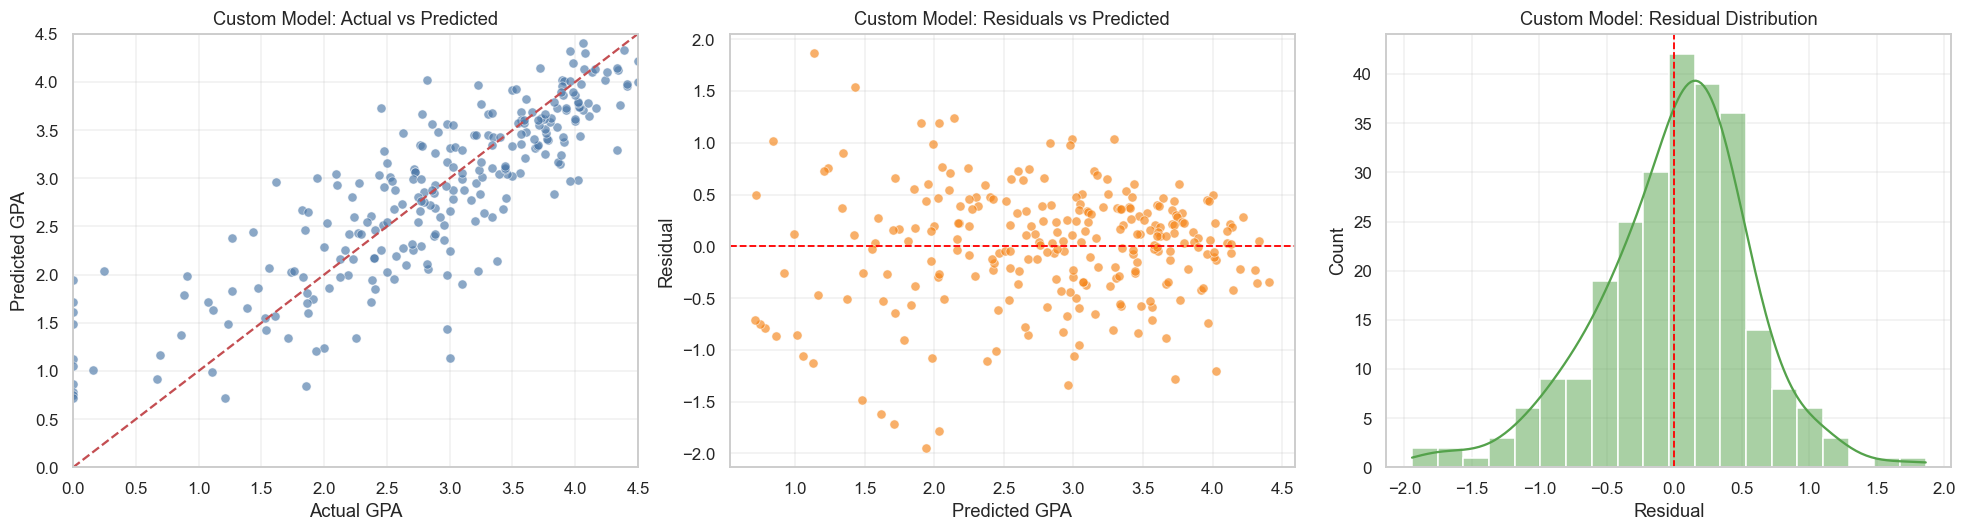

In [58]:
plot_prediction_diagnostics(custom_test_df, title_prefix='Custom Model')

### Experiment 4: Local Search around the Custom Architecture

In [63]:
# trying to find the local minimum around the custom model configuration by varying learning rate and batch size

base_layers = [
    {'units': 516, 'activation': 'tanh', 'batch_norm': True, 'dropout': 0.10},
    {'units': 128, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.20},
]

local_search_configs = [
    {'trial_name': 'SGD-lr0.00085-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00085, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00088-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00088, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00090-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00092-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00092, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00095-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00095, 'batch_size': 64},

    {'trial_name': 'SGD-lr0.00090-bs32', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 32},
    {'trial_name': 'SGD-lr0.00090-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00090-bs96', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 96},
    {'trial_name': 'SGD-lr0.00090-bs128', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 128},
]

local_search_results = []
local_search_models = {}
local_search_histories = {}
best_local_model = None
best_local_history = None
best_local_metrics = None
best_local_config = None
best_local_sort_key = None

for trial_idx, config in enumerate(local_search_configs, start=1):
    print_header(config['trial_name'])

    trial_model = build_dense_model(X_train.shape[1], config['layers'])
    trial_model = compile_regression_model(trial_model, optimizer_name=config['optimizer'], learning_rate=config['learning_rate'])

    trial_es = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1,
        mode='min',
    )

    trial_history = trial_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=200,
        batch_size=config['batch_size'],
        callbacks=[trial_es],
        verbose=1,
    )

    trial_val_metrics, _ = evaluate_model_original_scale(
        trial_model, X_val, y_val, scaler, split_name=f"{config['trial_name']} Validation", print_summary=False
    )
    trial_test_metrics, _ = evaluate_model_original_scale(
        trial_model, X_test, y_test, scaler, split_name=f"{config['trial_name']} Test", print_summary=False
    )

    best_epoch = int(np.argmin(trial_history.history['val_loss'])) + 1
    local_result = {
        'trial': trial_idx,
        'trial_name': config['trial_name'],
        'optimizer': config['optimizer'],
        'learning_rate': config['learning_rate'],
        'batch_size': config['batch_size'],
        'best_epoch': best_epoch,
        'val_rmse': trial_val_metrics['rmse'],
        'val_mae': trial_val_metrics['mae'],
        'val_r2_original': trial_val_metrics['r2_original'],
        'val_r2_scaled': trial_val_metrics['r2_scaled'],
        'test_rmse': trial_test_metrics['rmse'],
        'test_mae': trial_test_metrics['mae'],
        'test_r2_original': trial_test_metrics['r2_original'],
        'test_r2_scaled': trial_test_metrics['r2_scaled'],
        'architecture': ' | '.join([f"{layer['units']}:{layer['activation']}" for layer in config['layers']]),
    }
    local_search_results.append(local_result)
    local_search_models[config['trial_name']] = trial_model
    local_search_histories[config['trial_name']] = trial_history

    sort_key = (trial_val_metrics['r2_original'], -trial_val_metrics['rmse'])
    if best_local_sort_key is None or sort_key > best_local_sort_key:
        best_local_sort_key = sort_key
        best_local_model = trial_model
        best_local_history = trial_history
        best_local_metrics = local_result
        best_local_config = config

local_search_results_df = pd.DataFrame(local_search_results).sort_values(['val_r2_original', 'val_rmse'], ascending=[False, True]).reset_index(drop=True)
local_search_results_df.to_csv(
    project_path / 'second_term_gpa_regression' / 'trial_results' / 'local_search_results_regression_bayesian.csv',
    index=False,
)


========================== SGD-lr0.00085-bs64 ==========================

Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 1.4784 - mae: 0.9567 - r2: -21.4440 - rmse: 1.2159 - val_loss: 0.1043 - val_mae: 0.2855 - val_r2: -0.7869 - val_rmse: 0.3229
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.7147 - mae: 0.6631 - r2: -9.8505 - rmse: 0.8454 - val_loss: 0.0638 - val_mae: 0.2157 - val_r2: -0.0929 - val_rmse: 0.2526
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4823 - mae: 0.5357 - r2: -6.3216 - rmse: 0.6945 - val_loss: 0.0913 - val_mae: 0.2706 - val_r2: -0.5644 - val_rmse: 0.3022
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4453 - mae: 0.4961 - r2: -5.7609 - rmse: 0.6673 - val_loss: 0.0560 - val_mae: 0.2039 - val_r2: 0.0401 - val_rmse: 0.2367
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3409 - mae: 0.4527 - r2: -4.1749 - rmse: 0.5838 - val_loss: 0.0574 - val_mae: 0.1806 - val_r2: 0.0160 - val_rmse: 0.2396
Epoch 

In [68]:
# Save the best local search model
best_local_model.save(project_path / 'second_term_gpa_regression' / 'models' / 'local_search_model_bayesian.keras')

print('BEST LOCAL SEARCH CONFIG')
for key, value in best_local_config.items():
    print(f"{key}: {value}")

display(format_local_search_display(local_search_results_df))

BEST LOCAL SEARCH CONFIG
trial_name: SGD-lr0.00092-bs64
layers: [{'units': 516, 'activation': 'tanh', 'batch_norm': True, 'dropout': 0.1}, {'units': 128, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.2}]
optimizer: sgd
learning_rate: 0.00092
batch_size: 64


,Trial,Trial Name,Optimizer,Learning Rate,Batch Size,Best Epoch,Val RMSE (GPA),Val MAE (GPA),Val R² (Original GPA),Val R² (Scaled y),Test RMSE (GPA),Test MAE (GPA),Test R² (Original GPA),Test R² (Scaled y),Architecture
0,4,SGD-lr0.00092-bs64,sgd,0.00092,64,58,0.663095,0.459688,0.627944,0.627944,0.555741,0.426672,0.720052,0.720052,516:tanh | 128:elu
1,9,SGD-lr0.00090-bs128,sgd,0.00090,128,96,0.669906,0.455796,0.620262,0.620262,0.577026,0.447862,0.698198,0.698198,516:tanh | 128:elu
2,7,SGD-lr0.00090-bs64,sgd,0.00090,64,56,0.670283,0.458092,0.619834,0.619834,0.569111,0.437615,0.706421,0.706421,516:tanh | 128:elu
3,3,SGD-lr0.00090-bs64,sgd,0.00090,64,61,0.670444,0.464721,0.619652,0.619652,0.573299,0.441822,0.702084,0.702084,516:tanh | 128:elu
4,2,SGD-lr0.00088-bs64,sgd,0.00088,64,45,0.671402,0.461735,0.618564,0.618564,0.566830,0.437958,0.708769,0.708769,516:tanh | 128:elu
5,5,SGD-lr0.00095-bs64,sgd,0.00095,64,92,0.672169,0.457962,0.617692,0.617692,0.565710,0.430664,0.709919,0.709919,516:tanh | 128:elu
6,6,SGD-lr0.00090-bs32,sgd,0.00090,32,22,0.672902,0.458086,0.616858,0.616858,0.571205,0.444472,0.704257,0.704257,516:tanh | 128:elu
7,1,SGD-lr0.00085-bs64,sgd,0.00085,64,55,0.676375,0.471610,0.612892,0.612892,0.577227,0.447084,0.697988,0.697988,516:tanh | 128:elu
8,8,SGD-lr0.00090-bs96,sgd,0.00090,96,109,0.679409,0.469309,0.609412,0.609412,0.565049,0.434574,0.710597,0.710597,516:tanh | 128:elu


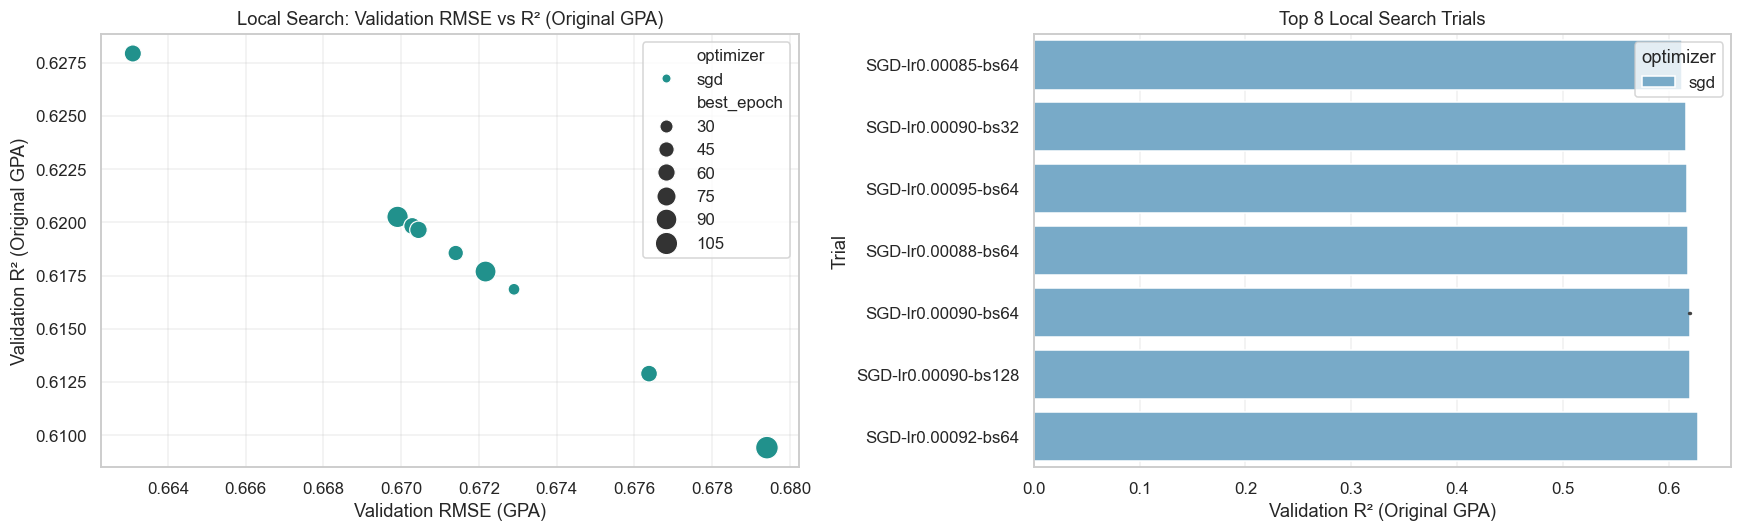

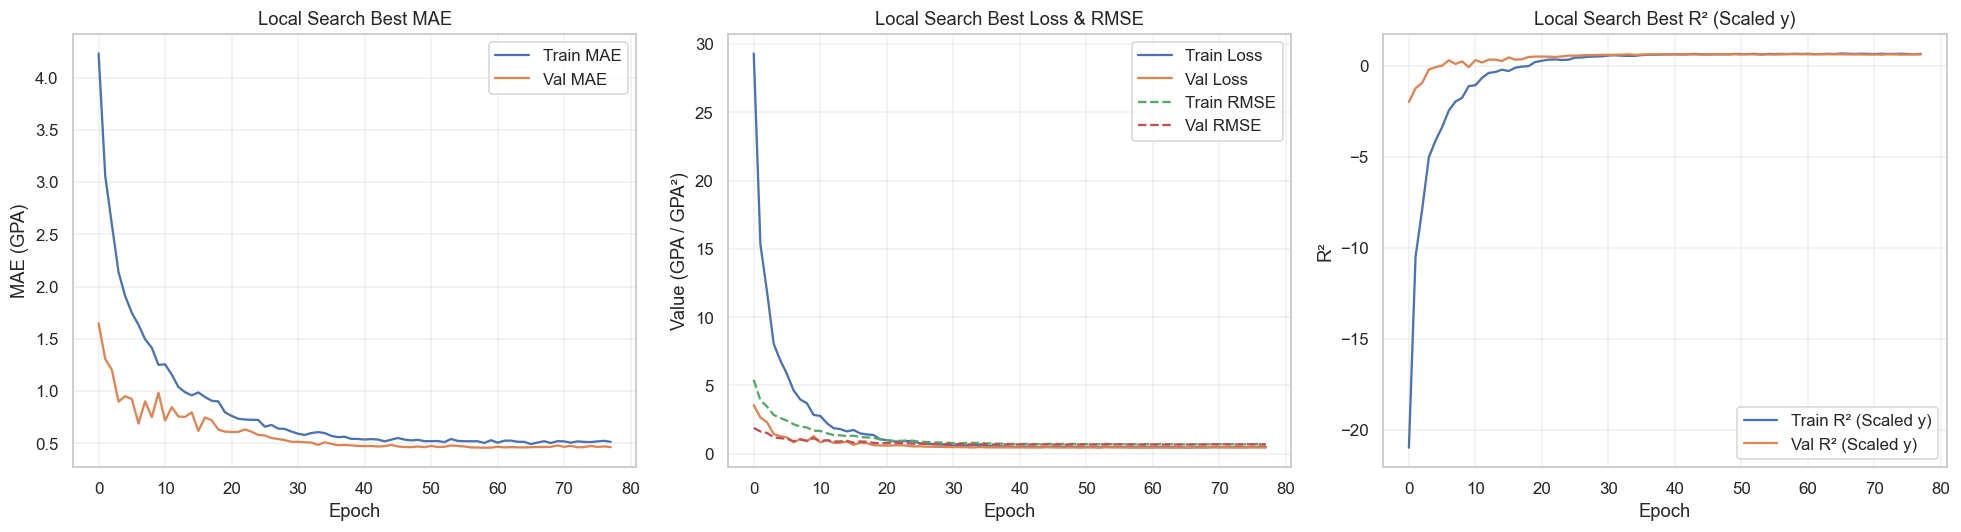


Best Epoch: 58
----------------------------------------
MAE (GPA)   -> Train: 0.5194 | Val: 0.4597
RMSE (GPA)  -> Train: 0.6978 | Val: 0.6631
Loss (GPA²) -> Train: 0.4869 | Val: 0.4397
R² (Scaled y) -> Train: 0.6350 | Val: 0.6279


In [74]:
plot_local_search_summary(local_search_results_df)
plot_regression_history(best_local_history, title_prefix='Local Search Best')

In [75]:
local_val_metrics, local_val_df = evaluate_model_original_scale(
    best_local_model, X_val, y_val, scaler, split_name='Local Search Validation'
)
local_test_metrics, local_test_df = evaluate_model_original_scale(
    best_local_model, X_test, y_test, scaler, split_name='Local Search Test'
)

local_summary_df = pd.DataFrame([local_val_metrics, local_test_metrics]).set_index('split')
display(format_metrics_display(local_summary_df))
display(local_test_df.head(15))

Local Search Validation RMSE: 0.6631
Local Search Validation MSE:  0.4397
Local Search Validation MAE:              0.4597
Local Search Validation R² (Original GPA): 0.6279
Local Search Validation R² (Scaled y):     0.6279
Local Search Test RMSE: 0.5557
Local Search Test MSE:  0.3088
Local Search Test MAE:              0.4267
Local Search Test R² (Original GPA): 0.7201
Local Search Test R² (Scaled y):     0.7201


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Local Search Validation,0.663095,0.439696,0.459688,0.627944,0.627944
Local Search Test,0.555741,0.308848,0.426672,0.720052,0.720052


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,3.000000,1.045326,1.954674,1.954674,3.820750
1,0.000000,1.934124,-1.934124,1.934124,3.740837
2,0.000000,1.723429,-1.723429,1.723429,2.970208
3,0.250000,1.965670,-1.715670,1.715670,2.943524
4,2.978261,1.338069,1.640192,1.640192,2.690230
5,0.000000,1.533679,-1.533679,1.533679,2.352172
6,0.000000,1.526931,-1.526931,1.526931,2.331518
7,3.375000,2.114753,1.260247,1.260247,1.588222
8,3.222222,1.975428,1.246794,1.246794,1.554495
9,1.619048,2.856802,-1.237754,1.237754,1.532034


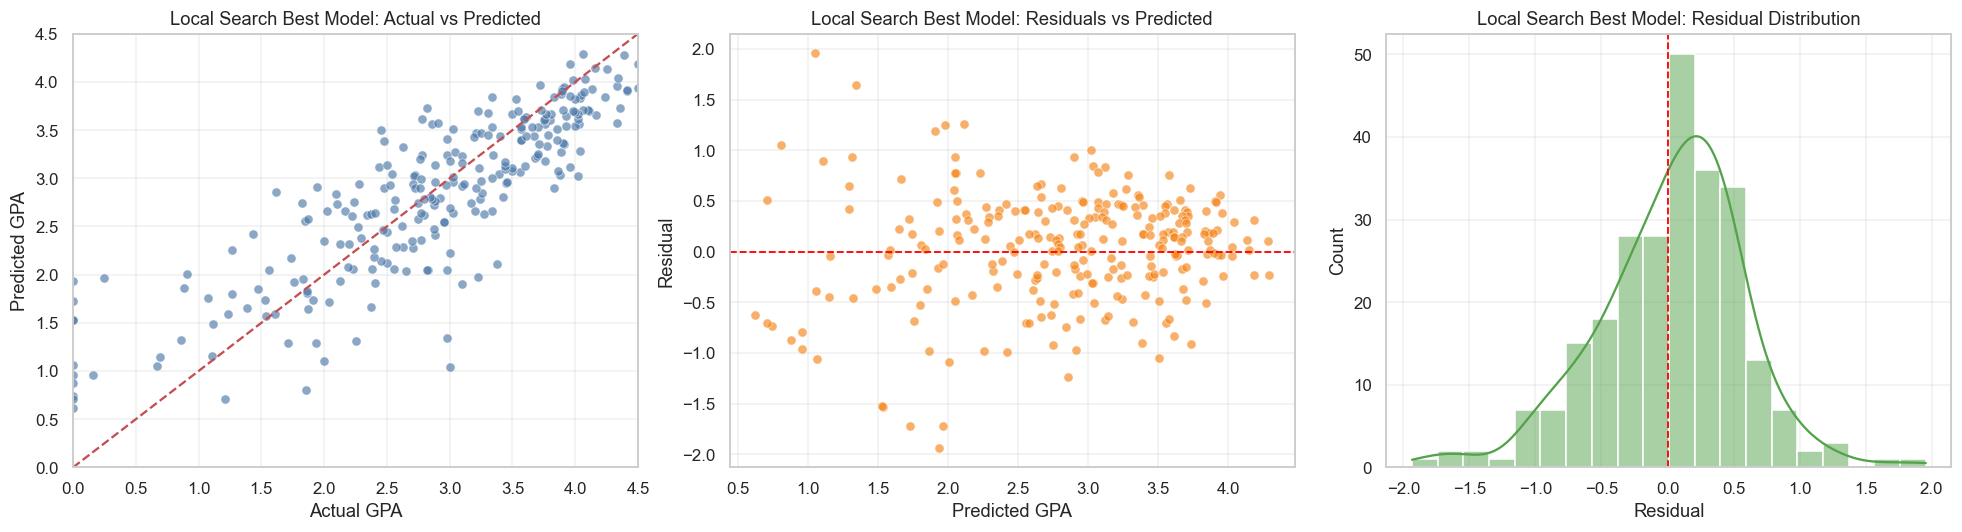

In [76]:
plot_prediction_diagnostics(local_test_df, title_prefix='Local Search Best Model')

### Model Comparison and Grouped Feature Importance

,Model,Split,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
0,Baseline,Validation,0.723310,0.523177,0.543962,0.557304,0.557304
1,Baseline,Test,0.654601,0.428503,0.503633,0.611594,0.611594
2,Hyperband Best,Validation,0.661731,0.437888,0.445898,0.629474,0.629474
3,Hyperband Best,Test,0.577222,0.333185,0.442390,0.697993,0.697993
4,Custom,Validation,0.674653,0.455157,0.468106,0.614861,0.614861
5,Custom,Test,0.565216,0.319469,0.428476,0.710426,0.710426
6,Local Search,Validation,0.663095,0.439696,0.459688,0.627944,0.627944
7,Local Search,Test,0.555741,0.308848,0.426672,0.720052,0.720052


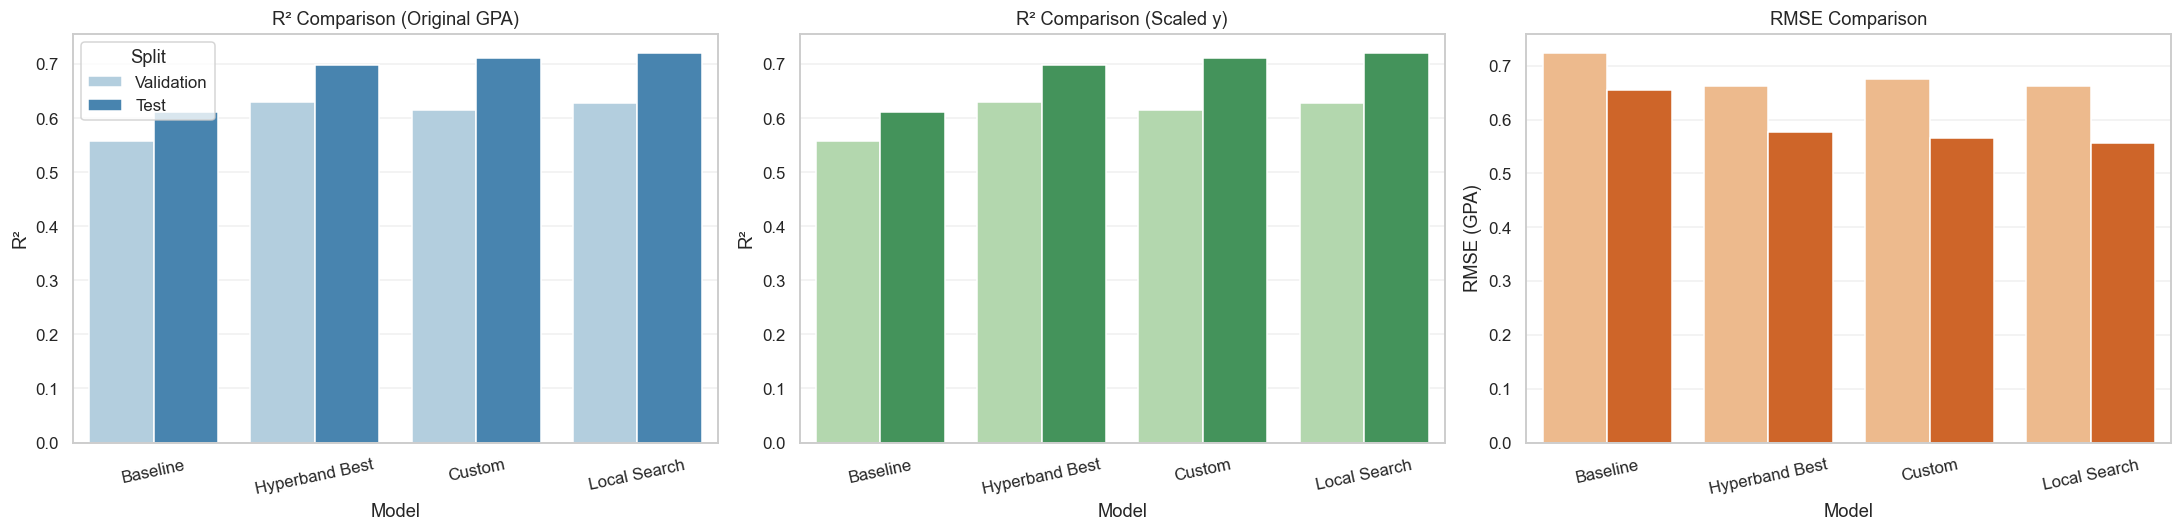

,Model,Split,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
0,Local Search,Test,0.555741,0.308848,0.426672,0.720052,0.720052
1,Custom,Test,0.565216,0.319469,0.428476,0.710426,0.710426
2,Hyperband Best,Test,0.577222,0.333185,0.442390,0.697993,0.697993
3,Baseline,Test,0.654601,0.428503,0.503633,0.611594,0.611594


In [77]:
experiment_models = {
    'Baseline': baseline_model,
    'Hyperband Best': best_model,
    'Custom': custom_model,
    'Local Search': best_local_model,
}

comparison_df = pd.DataFrame([
    {'Model': 'Baseline', 'Split': 'Validation', **{k: v for k, v in baseline_val_metrics.items() if k != 'split'}},
    {'Model': 'Baseline', 'Split': 'Test', **{k: v for k, v in baseline_test_metrics.items() if k != 'split'}},
    {'Model': 'Hyperband Best', 'Split': 'Validation', **{k: v for k, v in best_val_metrics.items() if k != 'split'}},
    {'Model': 'Hyperband Best', 'Split': 'Test', **{k: v for k, v in best_test_metrics.items() if k != 'split'}},
    {'Model': 'Custom', 'Split': 'Validation', **{k: v for k, v in custom_val_metrics.items() if k != 'split'}},
    {'Model': 'Custom', 'Split': 'Test', **{k: v for k, v in custom_test_metrics.items() if k != 'split'}},
    {'Model': 'Local Search', 'Split': 'Validation', **{k: v for k, v in local_val_metrics.items() if k != 'split'}},
    {'Model': 'Local Search', 'Split': 'Test', **{k: v for k, v in local_test_metrics.items() if k != 'split'}},
])

display(format_metrics_display(comparison_df))
plot_experiment_comparison(comparison_df)

validation_rank_df = comparison_df[comparison_df['Split'] == 'Test'].sort_values(['r2_original', 'rmse'], ascending=[False, True]).reset_index(drop=True)
display(format_metrics_display(validation_rank_df))

Selected model for grouped feature importance: Local Search


,Feature Group,RMSE Increase (Mean),RMSE Increase (Std),R² Drop (Mean),Grouped Columns
0,first_term_gpa,0.575780,0.018958,0.880911,first_term_gpa
1,high_school_average_mark,0.065600,0.003757,0.070004,high_school_average_mark
2,funding,0.020793,0.007410,0.021390,"funding_1, funding_2, funding_4, funding_5, fu..."
3,age_group,0.016620,0.001605,0.016997,age_group
4,english_grade,0.007074,0.002768,0.007179,english_grade
5,first_language,0.005673,0.002524,0.005750,"first_language_0, first_language_1, first_lang..."
6,coop,0.003971,0.001430,0.004016,coop
7,gender,0.003905,0.002439,0.003954,"gender_1, gender_2"
8,previous_education,0.002526,0.002487,0.002557,"previous_education_0, previous_education_1, pr..."
9,high_school_average_mark_missing,0.000780,0.000937,0.000787,high_school_average_mark_missing


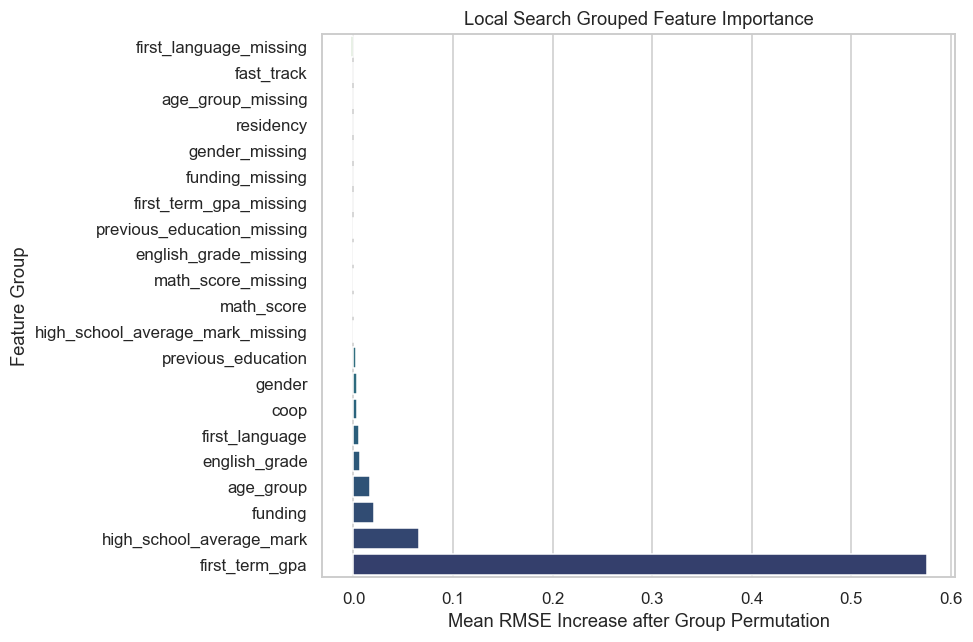

In [78]:
selected_model_name = validation_rank_df.iloc[0]['Model']
selected_model = experiment_models[selected_model_name]
print(f'Selected model for grouped feature importance: {selected_model_name}')

grouped_importance_df = compute_grouped_permutation_importance(
    selected_model,
    X_test,
    y_test,
    scaler,
    n_repeats=3,
    random_state=42,
)

display(grouped_importance_df)
plot_grouped_feature_importance(
    grouped_importance_df,
    title=f'{selected_model_name} Grouped Feature Importance',
)